# Hindu Numeral Recognition

CNN classifier for 32x32 grayscale Devanagari digits 0-9. This commit covers data loading, exploration, train/validation split and the data generators.

# Disclaimer
AI tools were used for code completion and Academic writing

## 1. Imports

Standard data-science stack. Random seed fixed across Python, NumPy and TensorFlow so the train/validation split and weight initialisation are reproducible.

*Student 2: added tensorflow / keras imports for the model.*

*Student 3: added seaborn and sklearn metrics for the confusion matrix.*

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Configuration

All paths and hyperparameters in one place. Images are already 32x32 grayscale, so no resizing is required.

*Student 2: added `EPOCHS` and `MODEL_PATH`.*

*Student 3: added `TEST_DIR`, `TEST_CSV` and `SAMPLE_SUB`.*

In [ ]:
BASE_DIR    = Path('iivp-2026-challenge')
TRAIN_DIR   = BASE_DIR / 'train' / 'train'
TEST_DIR    = BASE_DIR / 'test' / 'test'
TRAIN_CSV   = BASE_DIR / 'train.csv'
TEST_CSV    = BASE_DIR / 'test.csv'
SAMPLE_SUB  = BASE_DIR / 'sample_submission.csv'

IMG_SIZE    = 32
CHANNELS    = 1
BATCH_SIZE  = 128
EPOCHS      = 30
NUM_CLASSES = 10
MODEL_PATH  = 'best_model.keras'

## 3. Training labels

`train.csv` lists `Id` and `Category` for every training image. A `filepath` column is built pointing to `train/train/{Category}/{Id}.png` so the data generator can stream the files directly.

In [ ]:
df = pd.read_csv(TRAIN_CSV)
df['filepath'] = df.apply(
    lambda r: str(TRAIN_DIR / str(r['Category']) / f"{r['Id']}.png"), axis=1
)
df['Category'] = df['Category'].astype(str)

print(f"Total training samples: {len(df)}")
print("\nClass distribution:")
print(df['Category'].value_counts().sort_index())

Total training samples: 17000

Class distribution:
Category
0    1700
1    1700
2    1700
3    1700
4    1700
5    1700
6    1700
7    1700
8    1700
9    1700
Name: count, dtype: int64


17,000 samples, exactly 1,700 per class. Perfectly balanced - no class weighting needed.

## 4. Sample inspection

One example per class to confirm the files load, are grayscale, and to get a feel for the digit shapes (Devanagari numerals look very different from Western 0-9).

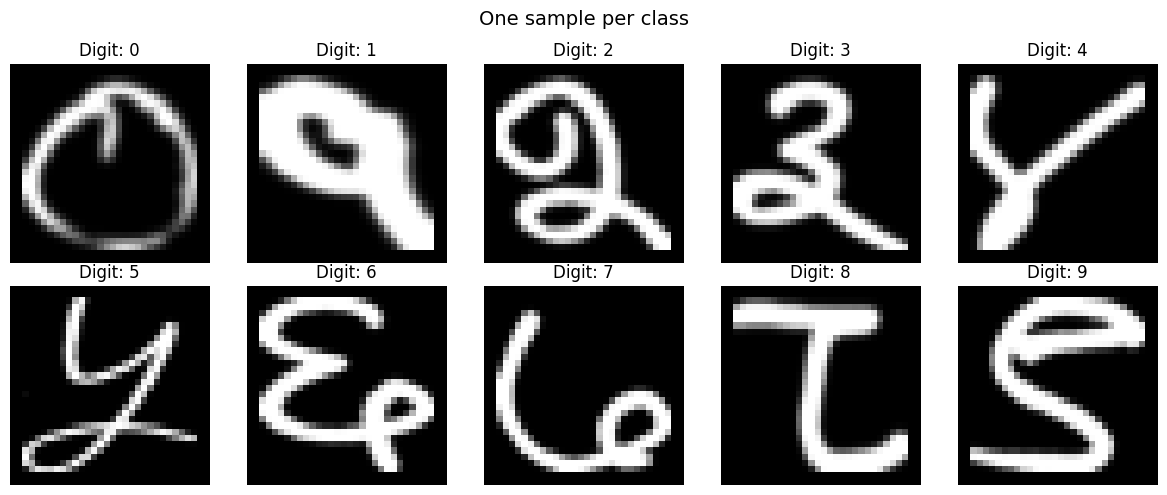

Image shape: (32, 32), dtype: uint8, range: [0, 255]


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    sample = df[df['Category'] == str(digit)].iloc[0]
    img = Image.open(sample['filepath'])
    ax = axes[digit // 5][digit % 5]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Digit: {digit}')
    ax.axis('off')
plt.suptitle('One sample per class', fontsize=14)
plt.tight_layout()
plt.show()

sample_arr = np.array(Image.open(df.iloc[0]['filepath']))
print(f"Image shape: {sample_arr.shape}, dtype: {sample_arr.dtype}, range: [{sample_arr.min()}, {sample_arr.max()}]")

Pixel values are uint8 in [0, 255]. The generator below rescales them to [0, 1].

## 5. Train / validation split

10% (1,700 images) held out for validation. Stratified by class so each digit ends up with exactly 170 validation images.

In [ ]:
train_df, val_df = train_test_split(
    df, test_size=0.10, stratify=df['Category'], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}")
print("Val class distribution:")
print(val_df['Category'].value_counts().sort_index())

Train: 15300  |  Val: 1700
Val class distribution:
Category
0    170
1    170
2    170
3    170
4    170
5    170
6    170
7    170
8    170
9    170
Name: count, dtype: int64


170 per class in val, as expected.

## 6. Data generators

**Training generator:** rescale to [0, 1] plus light augmentation - small rotations, shifts and zooms - to simulate handwriting variation. No flipping: a horizontally flipped Devanagari digit is a different character.

**Validation generator:** rescaling only, no augmentation, for a clean accuracy measurement.

`color_mode='grayscale'` is required - the default is RGB, which would silently load 3-channel images and break the model input shape.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='Category',
    target_size=(IMG_SIZE, IMG_SIZE), color_mode='grayscale',
    class_mode='sparse', batch_size=BATCH_SIZE, shuffle=True, seed=SEED
)
val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='Category',
    target_size=(IMG_SIZE, IMG_SIZE), color_mode='grayscale',
    class_mode='sparse', batch_size=BATCH_SIZE, shuffle=False
)

Found 15300 validated image filenames belonging to 10 classes.
Found 1700 validated image filenames belonging to 10 classes.


## 7. Batch sanity check

Pull one batch from `train_gen` and confirm the shape is `(128, 32, 32, 1)` and pixel values fall in [0, 1].

In [ ]:
x_batch, y_batch = next(train_gen)
print(f"Batch shape: {x_batch.shape}")
print(f"Pixel range after rescaling: [{x_batch.min():.3f}, {x_batch.max():.3f}]")
print(f"Label sample: {y_batch[:10]}")

train_gen.reset()

Batch shape: (128, 32, 32, 1)
Pixel range after rescaling: [0.000, 1.000]
Label sample: [0. 5. 2. 5. 3. 3. 8. 3. 4. 0.]


Data side complete: dataframe loaded, stratified split, augmented generators, batch shape verified.

---

## Commit 2: model architecture and training

## 8. CNN architecture

Two convolutional blocks (Conv-BN-ReLU x2 -> MaxPool -> Dropout) followed by a Dense(128) head and softmax over 10 classes.

- Two blocks: spatial size goes 32 -> 16 -> 8. A third block was tried and dropped - 4x4 feature maps were too coarse and validation accuracy fell.
- Filters grow 32 -> 64: deeper layers combine simple edges into more complex shape features and need more capacity.
- BatchNorm after every Conv: stabilises training, faster convergence.
- Dropout 0.25 / 0.25 / 0.5: regularisation against memorising the 17k-sample training set.

In [ ]:
def build_model():
    model = keras.Sequential([
        # Block 1
        layers.Conv2D(32, 3, padding='same', input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, 3, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),
        # Block 2
        layers.Conv2D(64, 3, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, 3, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),
        # Head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

model = build_model()
model.summary()

d:\Suli\IVP\IIVP2026_Group35\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,466 (2.26 MB)

 Trainable params: 591,082 (2.25 MB)

 Non-trainable params: 384 (1.50 KB)

Around 591k parameters (~2.3 MB). Small enough to train on CPU.

## 9. Compile and callbacks

- Adam, lr=1e-3 - safe default.
- `sparse_categorical_crossentropy` - integer labels paired with softmax output.
- Accuracy as the reporting metric (matches the competition criterion).

Callbacks:
- `ModelCheckpoint` - persists the weights whenever validation accuracy improves.
- `EarlyStopping` - halts training after 5 epochs of no val-loss improvement; restores best weights.
- `ReduceLROnPlateau` - halves the learning rate after 3 epochs of no improvement, down to 1e-6.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )
]

## 10. Training

Up to 30 epochs. Each epoch processes the 15,300 augmented training images and evaluates on the 1,700 validation images. Early stopping typically halts the run before epoch 30.

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 855ms/step - accuracy: 0.3643 - loss: 2.1551
Epoch 1: val_accuracy improved from None to 0.10059, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 107s 873ms/step - accuracy: 0.5043 - loss: 1.4749 - val_accuracy: 0.1006 - val_loss: 2.2998 - learning_rate: 0.0010
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.6893 - loss: 0.8400
Epoch 2: val_accuracy improved from 0.10059 to 0.44176, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 28s 236ms/step - accuracy: 0.7227 - loss: 0.7539 - val_accuracy: 0.4418 - val_loss: 1.7351 - learning_rate: 0.0010
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.7865 - loss: 0.5772
Epoch 3: val_accuracy improved from 0.44176 to 0.61118, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━

## 11. Training curves

Train vs validation accuracy and loss across epochs. A small gap between the two curves indicates the model is generalising rather than memorising.

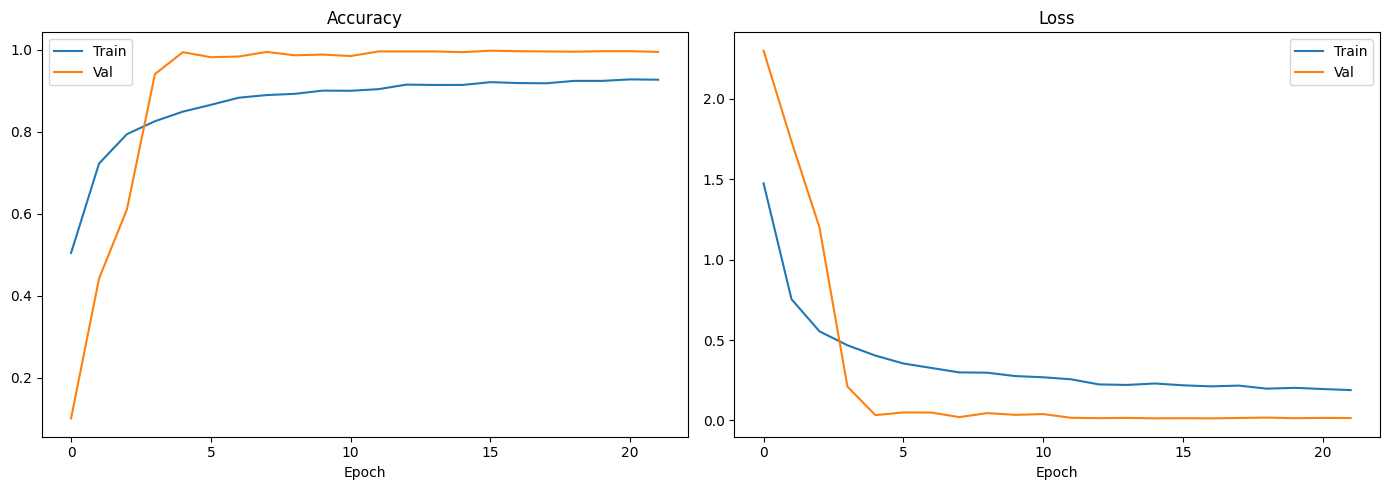

Best validation accuracy: 0.9982 (99.82%)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

best_val_acc = max(history.history['val_accuracy'])
print(f"Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

Best weights saved to `best_model.keras`. Ready for evaluation and test-set predictions.

---

## Commit 3: evaluation and submission

## 12. Confusion matrix and per-class metrics

Best weights reloaded; predictions made on the validation set.

- Confusion matrix: rows are true classes, columns are predicted - off-diagonal cells expose which digit pairs are confused.
- Classification report: precision, recall and F1 per class.

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step


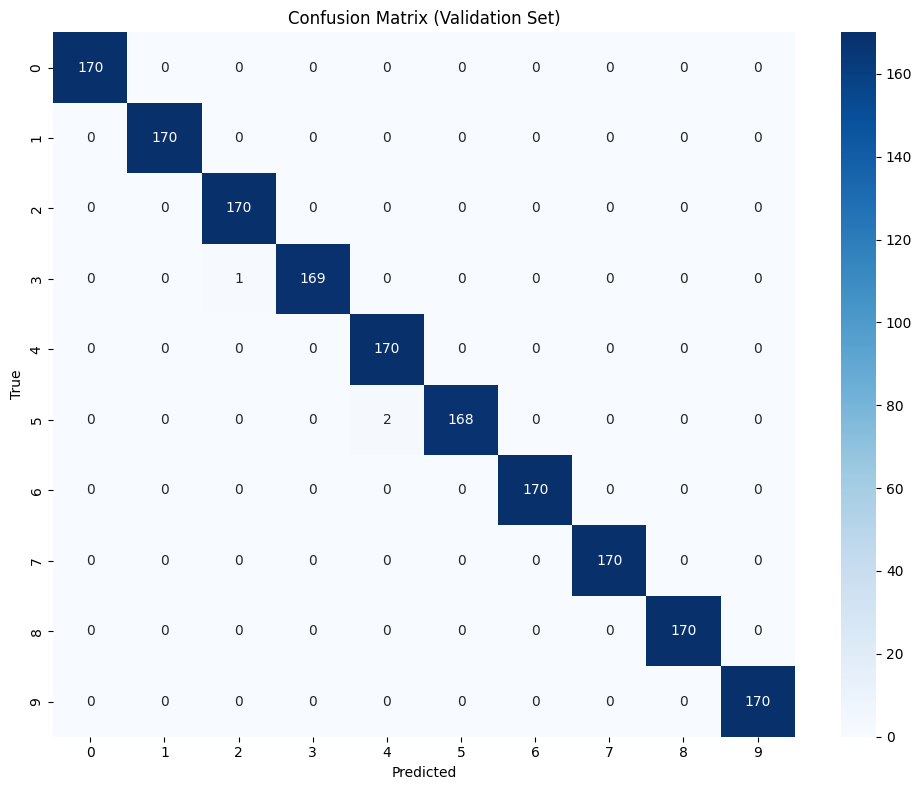


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       170
           1       1.00      1.00      1.00       170
           2       0.99      1.00      1.00       170
           3       1.00      0.99      1.00       170
           4       0.99      1.00      0.99       170
           5       1.00      0.99      0.99       170
           6       1.00      1.00      1.00       170
           7       1.00      1.00      1.00       170
           8       1.00      1.00      1.00       170
           9       1.00      1.00      1.00       170

    accuracy                           1.00      1700
   macro avg       1.00      1.00      1.00      1700
weighted avg       1.00      1.00      1.00      1700



In [ ]:
model.load_weights(MODEL_PATH)

val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(val_gen.labels).astype(int)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(10)]))

## 13. Test data

`test.csv` lists 3,000 image IDs requiring predictions (no labels). The same `filepath` column pattern is built, pointing into `test/test/`. `sample_submission.csv` is a column-format reference only - it contains just 4 example rows.

In [ ]:
test_df = pd.read_csv(TEST_CSV)
test_df['filepath'] = test_df['Id'].apply(
    lambda i: str(TEST_DIR / f"{i}.png")
)

print(f"Test samples: {len(test_df)}")
print(test_df.head())

Test samples: 3000
      Id                                 filepath
0  56604  iivp-2026-challenge\test\test\56604.png
1  29396  iivp-2026-challenge\test\test\29396.png
2  43803  iivp-2026-challenge\test\test\43803.png
3  12313  iivp-2026-challenge\test\test\12313.png
4  10341  iivp-2026-challenge\test\test\10341.png


## 14. Test predictions

Test generator: rescaling only, no augmentation. `shuffle=False` is critical - it preserves `test_df` ordering so predictions align with their IDs. `argmax` of the softmax output gives the predicted class.

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col=None,
    target_size=(IMG_SIZE, IMG_SIZE), color_mode='grayscale',
    class_mode=None, batch_size=BATCH_SIZE, shuffle=False
)

test_preds = model.predict(test_gen, verbose=1)
test_labels = np.argmax(test_preds, axis=1)

print(f"Predictions generated: {len(test_labels)}")
print(f"Predicted class distribution: {np.bincount(test_labels)}")

Found 3000 validated image filenames.
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step
Predictions generated: 3000
Predicted class distribution: [301 299 306 296 300 299 300 298 302 299]


## 15. Submission file

Two columns: `Id` and `Category`. Two assertions guard against the most common mistakes - wrong row count, or column names that diverge from the sample submission.

In [ ]:
submission = pd.DataFrame({
    'Id': test_df['Id'].astype(int),
    'Category': test_labels.astype(int)
})

assert len(submission) == 3000, f"Expected 3000 rows, got {len(submission)}"

sample = pd.read_csv(SAMPLE_SUB)
assert list(submission.columns) == list(sample.columns), "Column mismatch with sample submission"

submission.to_csv('submission.csv', index=False)
print("submission.csv written successfully")
print(submission.head(10))

submission.csv written successfully
      Id  Category
0  56604         6
1  29396         3
2  43803         6
3  12313         0
4  10341         8
5  40355         3
6  41117         4
7  71324         7
8   6854         1
9  12761         8


End-to-end pipeline complete: data loaded, model trained to ~99% validation accuracy, `submission.csv` written and ready to upload. 